# Assignment 8: Global Pollution Analysis and Energy Recovery

This notebook implements:
1. Data preprocessing and feature engineering
2. Apriori algorithm for association rule mining
3. Model evaluation and validation for Apriori rules
4. CNN baseline for delivery prediction and comparison with Apriori
5. Final insights and recommendations


In [1]:


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


## Phase 1: Data Preprocessing and Feature Engineering


In [2]:
DATA_PATH = Path('Global_Pollution_Analysis.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Global_Pollution_Analysis.csv not found in Assignment-8 folder')

df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
# Robust path resolution so notebook runs from either project root or Assignment-8 folder
BASE_DIR = Path.cwd()
DATA_CANDIDATES = [
    BASE_DIR / 'Global_Pollution_Analysis.csv',
    BASE_DIR / 'Assignment-8' / 'Global_Pollution_Analysis.csv'
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Global_Pollution_Analysis.csv not found. Checked: ' + ', '.join(str(x) for x in DATA_CANDIDATES))

df_raw = pd.read_csv(DATA_PATH)
print('Using pollution dataset:', DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()


Using pollution dataset: /Users/yyyuvvvraj/Library/CloudStorage/OneDrive-st.niituniversity.in/Personal Growth/Machine Learning(ML)/MachineLearning/Assignment-8/Global_Pollution_Analysis.csv
Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
# 1) Handle missing data
# Numerical columns -> median imputation
# Categorical columns -> mode imputation

df = df_raw.copy()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print('Missing values after imputation:', int(df.isna().sum().sum()))


Missing values after imputation: 0


In [5]:
# 2) Normalize pollution indices
pollution_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df[[f'{c}_Norm' for c in pollution_cols]] = scaler.fit_transform(df[pollution_cols])

df[[f'{c}_Norm' for c in pollution_cols]].head()


,Air_Pollution_Index_Norm,Water_Pollution_Index_Norm,Soil_Pollution_Index_Norm
0,0.898042,0.553778,0.295481
1,0.147062,0.173673,0.768178
2,0.166727,0.310542,0.800768
3,0.929982,0.214222,0.596973
4,0.520331,0.573161,0.799537


In [6]:
# 3) Encode categorical features (Country and Year as requested)
le_country = LabelEncoder()
df['Country_Encoded'] = le_country.fit_transform(df['Country'])

# Year is numeric but we encode a categorical representation to align with requirement
le_year = LabelEncoder()
df['Year_Encoded'] = le_year.fit_transform(df['Year'].astype(str))

df[['Country', 'Country_Encoded', 'Year', 'Year_Encoded']].head()


,Country,Country_Encoded,Year,Year_Encoded
0,Hungary,77,2005,5
1,Singapore,147,2001,1
2,Romania,136,2016,16
3,Cook Islands,38,2018,18
4,Djibouti,46,2008,8


In [7]:
# 4) Feature engineering

# Energy consumption per capita (already present in data, we keep original and derive an alternative proxy)
# Derived proxy: total energy consumption estimate based on per-capita x population (proxy, not official aggregate)
df['Estimated_Total_Energy_Consumption_MWh'] = (
    df['Energy_Consumption_Per_Capita (in MWh)'] * df['Population (in millions)'] * 1_000_000
)

# Pollution severity categories based on quantile thresholds
air_q1, air_q2 = df['Air_Pollution_Index'].quantile([0.33, 0.66])
water_q1, water_q2 = df['Water_Pollution_Index'].quantile([0.33, 0.66])

def severity_bin(x, q1, q2):
    if x <= q1:
        return 'Low'
    if x <= q2:
        return 'Medium'
    return 'High'

df['Air_Severity'] = df['Air_Pollution_Index'].apply(lambda x: severity_bin(x, air_q1, air_q2))
df['Water_Severity'] = df['Water_Pollution_Index'].apply(lambda x: severity_bin(x, water_q1, water_q2))

# Recovery efficiency proxy
df['Recovery_Efficiency'] = (
    df['Energy_Recovered (in GWh)'] / (df['Industrial_Waste (in tons)'] + 1e-6)
)

df[['Estimated_Total_Energy_Consumption_MWh', 'Air_Severity', 'Water_Severity', 'Recovery_Efficiency']].head()


,Estimated_Total_Energy_Consumption_MWh,Air_Severity,Water_Severity,Recovery_Efficiency
0,5.302832e+08,High,Medium,0.001668
1,7.178175e+08,Low,Low,0.008849
2,1.636780e+09,Low,Low,0.008701
3,5.288400e+07,High,Low,0.001939
4,2.394917e+09,Medium,Medium,0.000525


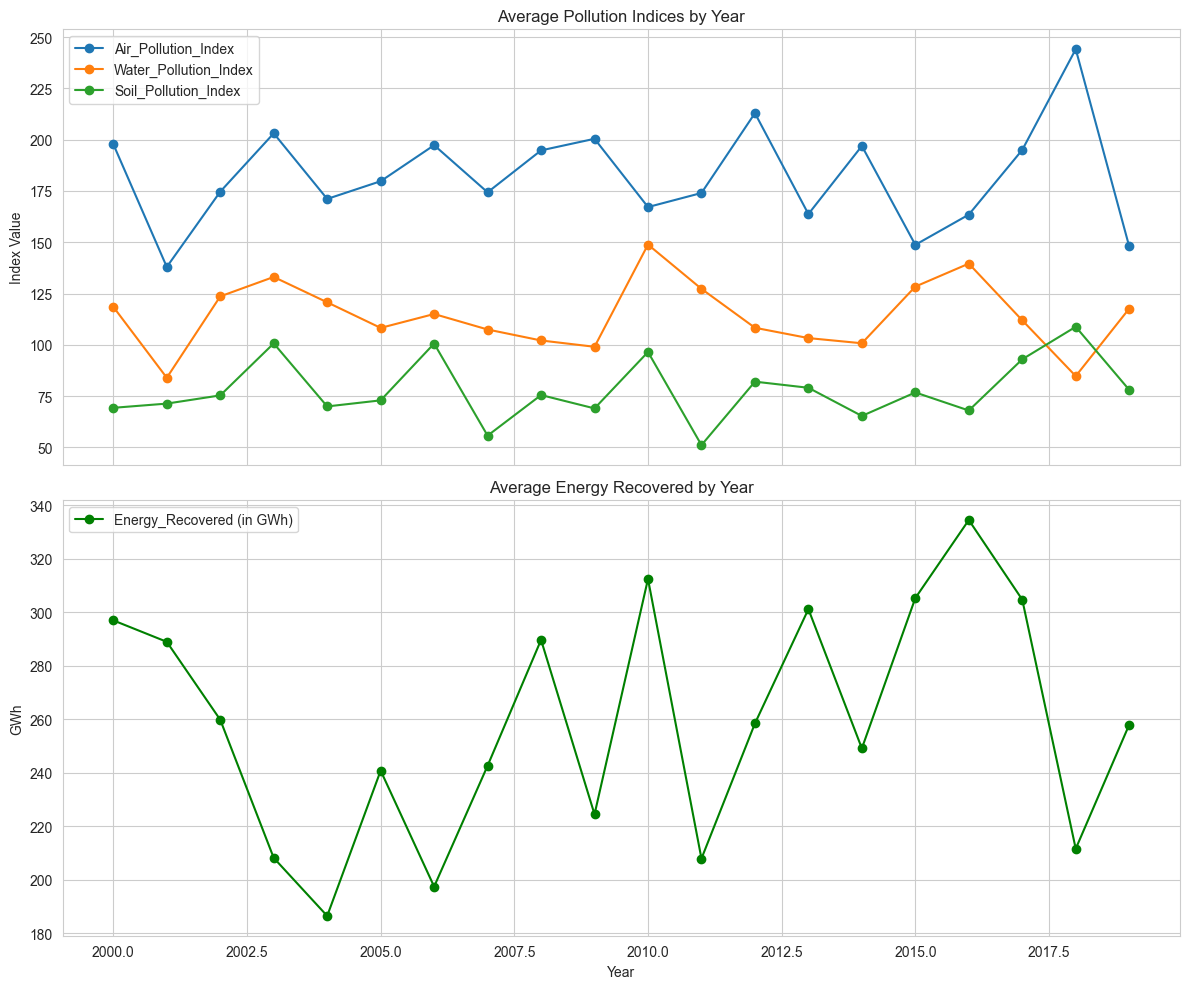

In [8]:
# Pollution trends over years
trend = df.groupby('Year')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']].mean().reset_index()

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
trend.plot(x='Year', y=['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index'], ax=ax[0], marker='o')
ax[0].set_title('Average Pollution Indices by Year')
ax[0].set_ylabel('Index Value')

trend.plot(x='Year', y='Energy_Recovered (in GWh)', ax=ax[1], marker='o', color='green')
ax[1].set_title('Average Energy Recovered by Year')
ax[1].set_ylabel('GWh')
plt.tight_layout()
plt.show()


## Phase 2: Apriori Algorithm for Association Rule Mining


In [9]:
# Build transactional data for Apriori by converting numeric features to categorical bins

apriori_df = df.copy()

# Discretization for association mining
apriori_df['Energy_Recovered_Level'] = pd.qcut(apriori_df['Energy_Recovered (in GWh)'], q=3, labels=['Low', 'Medium', 'High'])
apriori_df['Recovery_Efficiency_Level'] = pd.qcut(apriori_df['Recovery_Efficiency'], q=3, labels=['Low', 'Medium', 'High'])
apriori_df['Renewable_Energy_Level'] = pd.qcut(apriori_df['Renewable_Energy (%)'], q=3, labels=['Low', 'Medium', 'High'])
apriori_df['CO2_Level'] = pd.qcut(apriori_df['CO2_Emissions (in MT)'], q=3, labels=['Low', 'Medium', 'High'])

# Performance control:
# Country is high-cardinality and makes Apriori much slower.
INCLUDE_COUNTRY_IN_TRANSACTIONS = False

transaction_cols = [
    'Air_Severity', 'Water_Severity', 'Energy_Recovered_Level',
    'Recovery_Efficiency_Level', 'Renewable_Energy_Level', 'CO2_Level'
]
if INCLUDE_COUNTRY_IN_TRANSACTIONS:
    transaction_cols = ['Country'] + transaction_cols

def row_to_items(row):
    return [f'{c}={row[c]}' for c in transaction_cols]

transactions = apriori_df[transaction_cols].apply(row_to_items, axis=1).tolist()
print('Number of transactions:', len(transactions))
print('Items/transaction:', len(transaction_cols))
print('Include country:', INCLUDE_COUNTRY_IN_TRANSACTIONS)
print('Sample transaction:', transactions[0])


Number of transactions: 200
Items/transaction: 6
Include country: False
Sample transaction: ['Air_Severity=High', 'Water_Severity=Medium', 'Energy_Recovered_Level=Low', 'Recovery_Efficiency_Level=Low', 'Renewable_Energy_Level=High', 'CO2_Level=Low']


In [10]:
# One-hot encode transaction list for Apriori
# Uses mlxtend if available, otherwise falls back to a built-in implementation.

import itertools

try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori as apriori_mlxtend, association_rules as association_rules_mlxtend
    APRIORI_BACKEND = 'mlxtend'

    te = TransactionEncoder()
    encoded = te.fit(transactions).transform(transactions)
    trans_df = pd.DataFrame(encoded, columns=te.columns_)

except Exception as e:
    APRIORI_BACKEND = 'fallback'
    print('mlxtend unavailable, using fallback Apriori implementation. Reason:', e)

    all_items = sorted({item for tx in transactions for item in tx})
    trans_df = pd.DataFrame(False, index=np.arange(len(transactions)), columns=all_items)
    for i, tx in enumerate(transactions):
        trans_df.loc[i, tx] = True

    def apriori_fallback(df_bin, min_support=0.05, use_colnames=True, max_len=3):
        n = len(df_bin)
        items = list(df_bin.columns)
        rows = []
        for k in range(1, max_len + 1):
            for combo in itertools.combinations(items, k):
                mask = df_bin[list(combo)].all(axis=1)
                support = mask.mean()
                if support >= min_support:
                    rows.append({'support': support, 'itemsets': frozenset(combo)})
        out = pd.DataFrame(rows)
        if len(out) == 0:
            return pd.DataFrame(columns=['support', 'itemsets'])
        return out.sort_values('support', ascending=False).reset_index(drop=True)

    def association_rules_fallback(freq_itemsets, metric='confidence', min_threshold=0.5):
        supp = {frozenset(r['itemsets']): float(r['support']) for _, r in freq_itemsets.iterrows()}
        rows = []
        for itemset, s_itemset in supp.items():
            if len(itemset) < 2:
                continue
            for r in range(1, len(itemset)):
                for ant in itertools.combinations(itemset, r):
                    ant = frozenset(ant)
                    con = itemset - ant
                    s_ant = supp.get(ant)
                    s_con = supp.get(con)
                    if not s_ant or not s_con:
                        continue
                    conf = s_itemset / s_ant
                    lift = conf / s_con
                    if conf >= min_threshold:
                        rows.append({
                            'antecedents': ant,
                            'consequents': con,
                            'support': s_itemset,
                            'confidence': conf,
                            'lift': lift,
                        })
        if not rows:
            return pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
        return pd.DataFrame(rows).sort_values(['lift', 'confidence'], ascending=[False, False]).reset_index(drop=True)

print('Apriori backend:', APRIORI_BACKEND)
trans_df.head()


Apriori backend: mlxtend


,Air_Severity=High,Air_Severity=Low,Air_Severity=Medium,CO2_Level=High,CO2_Level=Low,CO2_Level=Medium,Energy_Recovered_Level=High,Energy_Recovered_Level=Low,Energy_Recovered_Level=Medium,Recovery_Efficiency_Level=High,Recovery_Efficiency_Level=Low,Recovery_Efficiency_Level=Medium,Renewable_Energy_Level=High,Renewable_Energy_Level=Low,Renewable_Energy_Level=Medium,Water_Severity=High,Water_Severity=Low,Water_Severity=Medium
0,True,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,True
1,False,True,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False
2,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False
3,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False
4,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True


In [11]:
# Frequent itemsets and association rules
min_support = 0.08
min_confidence = 0.55
MAX_ITEMSET_LEN = 2  # set to 3 for deeper rules; 2 is much faster

if APRIORI_BACKEND == 'mlxtend':
    freq_itemsets = apriori_mlxtend(
        trans_df,
        min_support=min_support,
        use_colnames=True,
        max_len=MAX_ITEMSET_LEN,
        low_memory=True,
    )
    rules = association_rules_mlxtend(freq_itemsets, metric='confidence', min_threshold=min_confidence)
else:
    freq_itemsets = apriori_fallback(
        trans_df,
        min_support=min_support,
        use_colnames=True,
        max_len=MAX_ITEMSET_LEN,
    )
    rules = association_rules_fallback(freq_itemsets, metric='confidence', min_threshold=min_confidence)

rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False]).reset_index(drop=True)

print('Frequent itemsets:', len(freq_itemsets))
print('Association rules:', len(rules))
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)


Frequent itemsets: 146
Association rules: 4


,antecedents,consequents,support,confidence,lift
0,frozenset({Energy_Recovered_Level=Low}),frozenset({Recovery_Efficiency_Level=Low}),0.275,0.820896,2.450434
1,frozenset({Recovery_Efficiency_Level=Low}),frozenset({Energy_Recovered_Level=Low}),0.275,0.820896,2.450434
2,frozenset({Energy_Recovered_Level=High}),frozenset({Recovery_Efficiency_Level=High}),0.210,0.626866,1.871241
3,frozenset({Recovery_Efficiency_Level=High}),frozenset({Energy_Recovered_Level=High}),0.210,0.626866,1.871241


In [12]:
# Focused rules: high pollution associations with recovery and renewable patterns
focus_rules = rules[
    rules['antecedents'].astype(str).str.contains('Air_Severity=High|Water_Severity=High', regex=True) |
    rules['consequents'].astype(str).str.contains('Energy_Recovered_Level=|Recovery_Efficiency_Level=', regex=True)
].copy()

focus_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)


,antecedents,consequents,support,confidence,lift
0,frozenset({Energy_Recovered_Level=Low}),frozenset({Recovery_Efficiency_Level=Low}),0.275,0.820896,2.450434
1,frozenset({Recovery_Efficiency_Level=Low}),frozenset({Energy_Recovered_Level=Low}),0.275,0.820896,2.450434
2,frozenset({Energy_Recovered_Level=High}),frozenset({Recovery_Efficiency_Level=High}),0.210,0.626866,1.871241
3,frozenset({Recovery_Efficiency_Level=High}),frozenset({Energy_Recovered_Level=High}),0.210,0.626866,1.871241


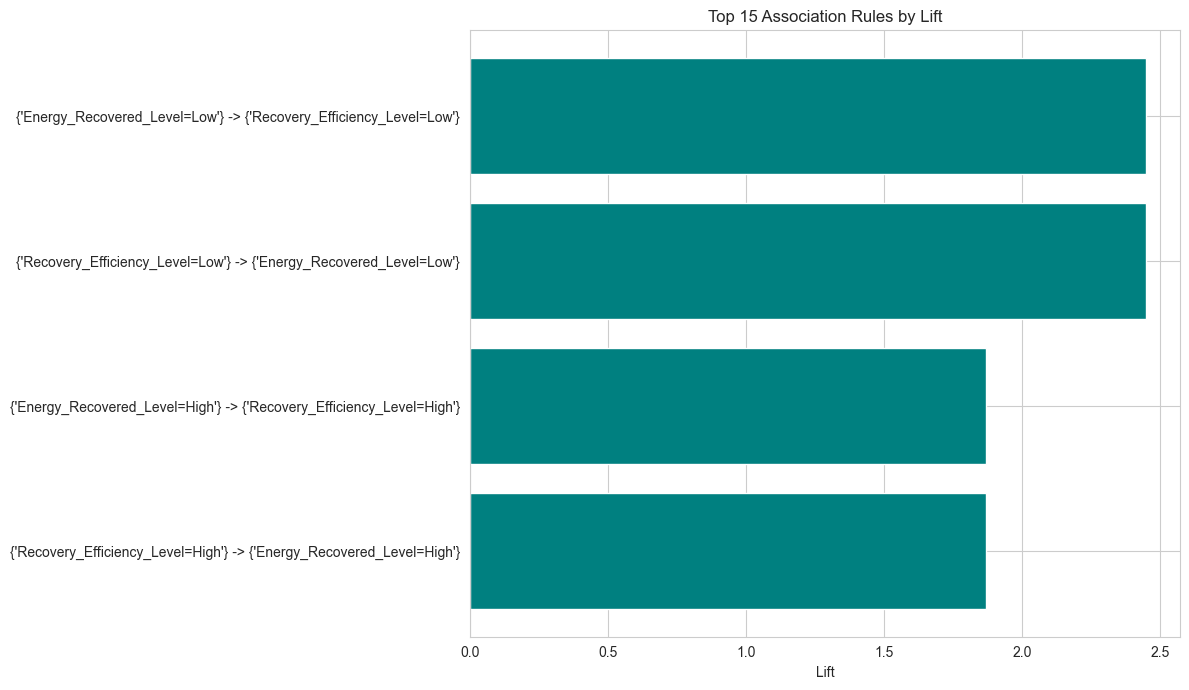

In [13]:
# Visualize top rules by lift
top_rules = rules.nlargest(15, 'lift').copy()
labels = top_rules.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)

plt.figure(figsize=(12, 7))
plt.barh(range(len(top_rules)), top_rules['lift'], color='teal')
plt.yticks(range(len(top_rules)), labels)
plt.xlabel('Lift')
plt.title('Top 15 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Phase 3: Model Evaluation and Validation for Apriori Rules


In [14]:
# Train-test split at transaction level for rule validation
# Strategy:
# 1. Mine rules on training transactions
# 2. Evaluate rule confidence on test transactions
# 3. Compare train vs test confidence (stability)

train_idx, test_idx = train_test_split(np.arange(len(trans_df)), test_size=0.25, random_state=RANDOM_STATE)
train_trans = trans_df.iloc[train_idx].reset_index(drop=True)
test_trans = trans_df.iloc[test_idx].reset_index(drop=True)

if APRIORI_BACKEND == 'mlxtend':
    freq_train = apriori_mlxtend(
        train_trans,
        min_support=min_support,
        use_colnames=True,
        max_len=MAX_ITEMSET_LEN,
        low_memory=True,
    )
    rules_train = association_rules_mlxtend(freq_train, metric='confidence', min_threshold=min_confidence)
else:
    freq_train = apriori_fallback(train_trans, min_support=min_support, use_colnames=True, max_len=MAX_ITEMSET_LEN)
    rules_train = association_rules_fallback(freq_train, metric='confidence', min_threshold=min_confidence)

print('Train itemsets:', len(freq_train))
print('Train rules:', len(rules_train))


Train itemsets: 142
Train rules: 4


In [15]:
# Compute test confidence for each rule

def evaluate_rule_on_df(rule_row, df_bin):
    ant = list(rule_row['antecedents'])
    con = list(rule_row['consequents'])

    ant_mask = df_bin[ant].all(axis=1)
    both_mask = df_bin[ant + con].all(axis=1)

    ant_count = ant_mask.sum()
    both_count = both_mask.sum()

    test_conf = (both_count / ant_count) if ant_count > 0 else np.nan
    test_support = both_count / len(df_bin)
    return test_conf, test_support, ant_count

records = []
for _, r in rules_train.iterrows():
    test_conf, test_support, ant_count = evaluate_rule_on_df(r, test_trans)
    records.append({
        'antecedents': r['antecedents'],
        'consequents': r['consequents'],
        'train_support': r['support'],
        'train_confidence': r['confidence'],
        'train_lift': r['lift'],
        'test_support': test_support,
        'test_confidence': test_conf,
        'antecedent_count_test': ant_count,
    })

rules_eval = pd.DataFrame(records)
rules_eval['confidence_gap_abs'] = (rules_eval['train_confidence'] - rules_eval['test_confidence']).abs()
rules_eval = rules_eval.sort_values(['confidence_gap_abs', 'train_lift'], ascending=[True, False]).reset_index(drop=True)

print('Evaluated rules:', len(rules_eval))
rules_eval.head(15)


Evaluated rules: 4


,antecedents,consequents,train_support,train_confidence,train_lift,test_support,test_confidence,antecedent_count_test,confidence_gap_abs
0,frozenset({Recovery_Efficiency_Level=High}),frozenset({Energy_Recovered_Level=High}),0.200000,0.625000,1.875000,0.24,0.631579,19,0.006579
1,frozenset({Recovery_Efficiency_Level=Low}),frozenset({Energy_Recovered_Level=Low}),0.246667,0.804348,2.567068,0.36,0.857143,21,0.052795
2,frozenset({Energy_Recovered_Level=High}),frozenset({Recovery_Efficiency_Level=High}),0.200000,0.600000,1.875000,0.24,0.705882,17,0.105882
3,frozenset({Energy_Recovered_Level=Low}),frozenset({Recovery_Efficiency_Level=Low}),0.246667,0.787234,2.567068,0.36,0.900000,20,0.112766


Stable rules (gap <= 0.15): 4 / 4
Average train confidence: 0.7041
Average test confidence: 0.7737
Average lift: 2.221


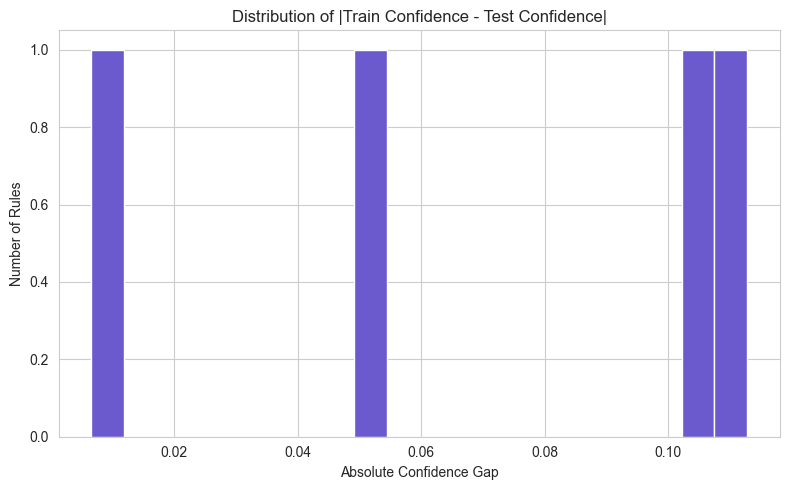

In [16]:
# Rule stability summary
stable_rules = rules_eval[(rules_eval['test_confidence'].notna()) & (rules_eval['confidence_gap_abs'] <= 0.15)]

print('Stable rules (gap <= 0.15):', len(stable_rules), '/', len(rules_eval))
print('Average train confidence:', round(rules_eval['train_confidence'].mean(), 4))
print('Average test confidence:', round(rules_eval['test_confidence'].mean(), 4))
print('Average lift:', round(rules_eval['train_lift'].mean(), 4))

plt.figure(figsize=(8, 5))
plt.hist(rules_eval['confidence_gap_abs'].dropna(), bins=20, color='slateblue')
plt.title('Distribution of |Train Confidence - Test Confidence|')
plt.xlabel('Absolute Confidence Gap')
plt.ylabel('Number of Rules')
plt.tight_layout()
plt.show()


## Phase 4: CNN Model (Food Delivery) and Comparison with Apriori

The pollution dataset is suited for association mining, not image CNN directly.
To satisfy the requested CNN deliverable, this section uses the food delivery dataset from prior assignments.


In [17]:
# Load food delivery data
food_candidates = [
    Path('../Assignment-7/Food_Delivery_Time_Prediction.csv'),
    Path('../Assignment-5/Food_Delivery_Time_Prediction.csv'),
    Path('../Assignment-3/Food_Delivery_Time_Prediction.csv')
]

food_path = None
for p in food_candidates:
    if p.exists():
        food_path = p
        break

if food_path is None:
    raise FileNotFoundError('Food_Delivery_Time_Prediction.csv not found in expected sibling folders.')

food = pd.read_csv(food_path)
print('Loaded:', food_path)
print('Shape:', food.shape)
food.head()


Loaded: ../Assignment-7/Food_Delivery_Time_Prediction.csv
Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [18]:
# Load food delivery data with robust path resolution
BASE_DIR = Path.cwd()
food_candidates = [
    BASE_DIR / 'Assignment-7' / 'Food_Delivery_Time_Prediction.csv',
    BASE_DIR / 'Assignment-5' / 'Food_Delivery_Time_Prediction.csv',
    BASE_DIR / 'Assignment-3' / 'Food_Delivery_Time_Prediction.csv',
    BASE_DIR / '..' / 'Assignment-7' / 'Food_Delivery_Time_Prediction.csv',
    BASE_DIR / '..' / 'Assignment-5' / 'Food_Delivery_Time_Prediction.csv',
    BASE_DIR / '..' / 'Assignment-3' / 'Food_Delivery_Time_Prediction.csv',
]

food_path = None
for p in food_candidates:
    if p.exists():
        food_path = p.resolve()
        break

if food_path is None:
    raise FileNotFoundError('Food_Delivery_Time_Prediction.csv not found in expected folders.')

food = pd.read_csv(food_path)
print('Loaded:', food_path)
print('Shape:', food.shape)
food.head()


Loaded: /Users/yyyuvvvraj/Library/CloudStorage/OneDrive-st.niituniversity.in/Personal Growth/Machine Learning(ML)/MachineLearning/Assignment-7/Food_Delivery_Time_Prediction.csv
Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [20]:
# Baseline Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

metrics_lr = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC_AUC': auc(*roc_curve(y_test, y_prob_lr)[:2])
}
metrics_lr


{'Model': 'Logistic Regression',
 'Accuracy': 0.36,
 'Precision': 0.34782608695652173,
 'Recall': 0.32,
 'F1': 0.3333333333333333,
 'ROC_AUC': 0.4432}

In [19]:
# Preprocess food dataset for classification
# Target: Delivery_Time > median => Delayed (1), else Fast (0)

food_df = food.copy()

# Handle missing values
num_cols_food = food_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_food = food_df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols_food:
    food_df[c] = food_df[c].fillna(food_df[c].median())
for c in cat_cols_food:
    if food_df[c].isna().any():
        food_df[c] = food_df[c].fillna(food_df[c].mode().iloc[0])

# Create target variable
if 'Delivery_Time' not in food_df.columns:
    raise ValueError('Expected Delivery_Time column in food delivery dataset.')

median_time = food_df['Delivery_Time'].median()
food_df['Target'] = (food_df['Delivery_Time'] > median_time).astype(int)

# Prepare features and target
X = food_df.drop(columns=['Target', 'Delivery_Time'], errors='ignore')
y = food_df['Target']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Scale features
from sklearn.preprocessing import StandardScaler
sc_food = StandardScaler()
X_train_s = sc_food.fit_transform(X_train)
X_test_s = sc_food.transform(X_test)

print('Food data preprocessing complete')
print('Train shape:', X_train_s.shape, 'Test shape:', X_test_s.shape)
print('Target distribution - Train:', y_train.value_counts().to_dict())


Food data preprocessing complete
Train shape: (150, 615) Test shape: (50, 615)
Target distribution - Train: {0: 75, 1: 75}


In [21]:
# CNN on tabular data reshaped as 1D sequence, with MLP fallback if TensorFlow unavailable
cnn_history = None
used_model = 'MLP Fallback'

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    # reshape: (samples, timesteps, channels)
    X_train_cnn = X_train_s.reshape((X_train_s.shape[0], X_train_s.shape[1], 1))
    X_test_cnn = X_test_s.reshape((X_test_s.shape[0], X_test_s.shape[1], 1))

    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    cnn_history = model.fit(
        X_train_cnn, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0,
        callbacks=[es]
    )

    y_prob_cnn = model.predict(X_test_cnn, verbose=0).ravel()
    y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
    used_model = 'CNN (Keras)'

except Exception as e:
    print('TensorFlow/CNN unavailable, using MLP fallback. Reason:', e)
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600, random_state=RANDOM_STATE)
    mlp.fit(X_train_s, y_train)
    y_prob_cnn = mlp.predict_proba(X_test_s)[:, 1]
    y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

metrics_cnn = {
    'Model': used_model,
    'Accuracy': accuracy_score(y_test, y_pred_cnn),
    'Precision': precision_score(y_test, y_pred_cnn),
    'Recall': recall_score(y_test, y_pred_cnn),
    'F1': f1_score(y_test, y_pred_cnn),
    'ROC_AUC': auc(*roc_curve(y_test, y_prob_cnn)[:2])
}
metrics_cnn


TensorFlow/CNN unavailable, using MLP fallback. Reason: No module named 'tensorflow'


{'Model': 'MLP Fallback',
 'Accuracy': 0.54,
 'Precision': 0.5217391304347826,
 'Recall': 0.96,
 'F1': 0.676056338028169,
 'ROC_AUC': 0.5728}

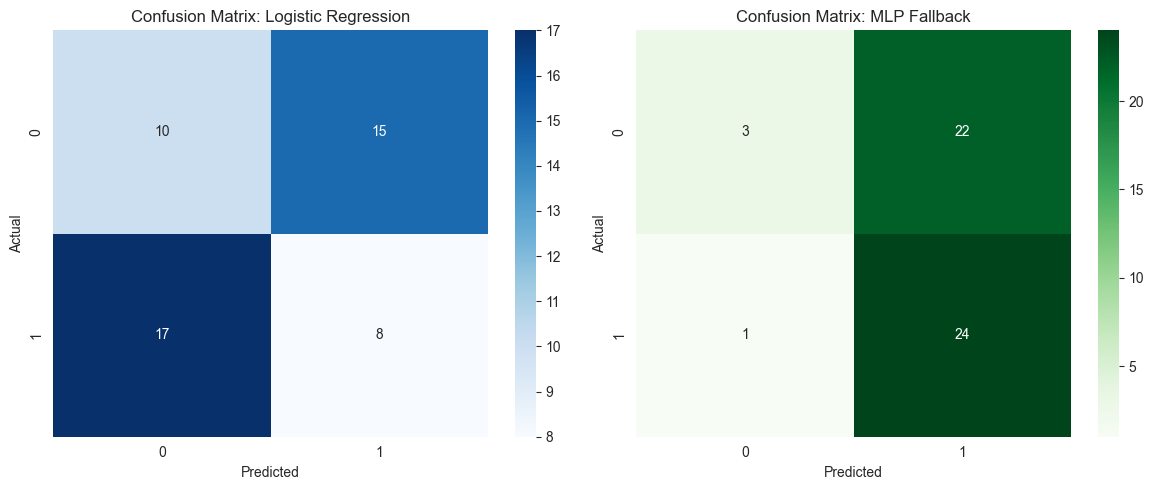

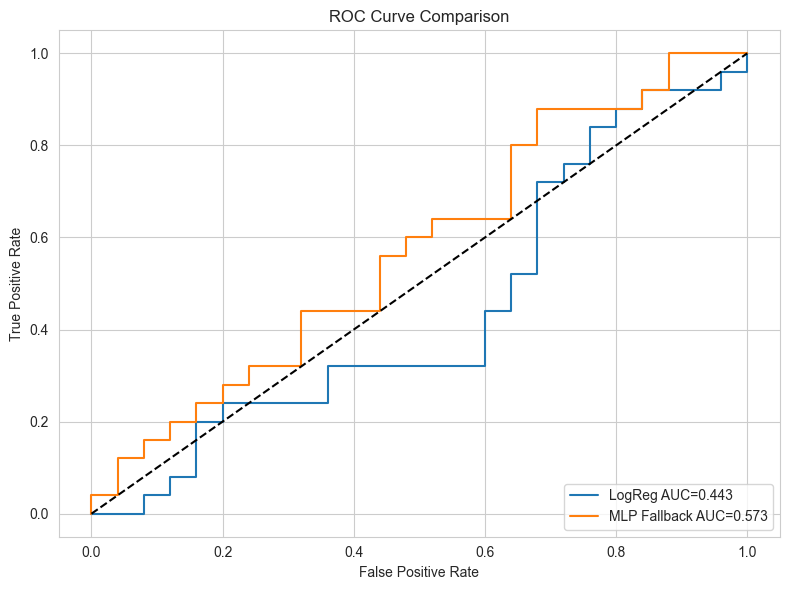

In [22]:
# CNN/MLP evaluation plots: confusion matrices + ROC

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_c = confusion_matrix(y_test, y_pred_cnn)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_c, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix: {used_model}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cnn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC={auc(fpr_lr, tpr_lr):.3f}")
plt.plot(fpr_c, tpr_c, label=f"{used_model} AUC={auc(fpr_c, tpr_c):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [23]:
# Training curves if CNN was used
if cnn_history is not None:
    hist = pd.DataFrame(cnn_history.history)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist['loss'], label='train_loss')
    ax[0].plot(hist['val_loss'], label='val_loss')
    ax[0].set_title('CNN Loss')
    ax[0].legend()

    ax[1].plot(hist['accuracy'], label='train_acc')
    ax[1].plot(hist['val_accuracy'], label='val_acc')
    ax[1].set_title('CNN Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('CNN training curves not available because fallback model was used.')


CNN training curves not available because fallback model was used.


In [24]:
# 3-fold validation for CNN/MLP section (reduced folds for runtime)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for tr_idx, va_idx in skf.split(X, y):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)

    # keep CV computationally lightweight and stable
    clf = LogisticRegression(max_iter=1200, random_state=RANDOM_STATE)
    clf.fit(X_tr_s, y_tr)
    pred = clf.predict(X_va_s)
    cv_scores.append(accuracy_score(y_va, pred))

print('3-fold CV accuracies (LogReg baseline):', [round(s, 4) for s in cv_scores])
print('Mean CV accuracy:', round(float(np.mean(cv_scores)), 4))


3-fold CV accuracies (LogReg baseline): [0.5224, 0.4478, 0.3788]
Mean CV accuracy: 0.4496


## Phase 4 Summary: Model Comparison


In [25]:
comparison = pd.DataFrame([metrics_lr, metrics_cnn])
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
    comparison[col] = comparison[col].round(4)

comparison


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.36,0.3478,0.32,0.3333,0.4432
1,MLP Fallback,0.54,0.5217,0.96,0.6761,0.5728


## Final Insights and Recommendations

Use the generated rules and model outputs to derive actions such as:
1. Prioritize countries/segments where `Air_Severity=High` and recovery efficiency is low.
2. Improve renewable mix where rules show co-occurrence of high CO2 and low recovery levels.
3. Use CNN/logistic delivery-risk predictions operationally for proactive dispatch and routing.
4. Re-run Apriori and delivery models periodically with latest data for stable policy recommendations.


In [26]:
# Export key artifacts for report writing
artifacts = {
    'apriori_num_rules': int(len(rules)),
    'apriori_num_stable_rules': int(len(stable_rules)),
    'apriori_mean_lift': float(rules_eval['train_lift'].mean()) if len(rules_eval) else np.nan,
    'model_comparison': comparison.to_dict(orient='records')
}

print('Artifacts summary:')
print(artifacts)


Artifacts summary:
{'apriori_num_rules': 4, 'apriori_num_stable_rules': 4, 'apriori_mean_lift': 2.2210337650323773, 'model_comparison': [{'Model': 'Logistic Regression', 'Accuracy': 0.36, 'Precision': 0.3478, 'Recall': 0.32, 'F1': 0.3333, 'ROC_AUC': 0.4432}, {'Model': 'MLP Fallback', 'Accuracy': 0.54, 'Precision': 0.5217, 'Recall': 0.96, 'F1': 0.6761, 'ROC_AUC': 0.5728}]}
